# Predict Podcast Listening Time

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s5e4/sample_submission.csv
/kaggle/input/competitions/playground-series-s5e4/train.csv
/kaggle/input/competitions/playground-series-s5e4/test.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


import warnings
warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s5e4/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s5e4/test.csv")

In [4]:
print(train.shape)
print(test.shape)

(750000, 12)
(250000, 11)


In [5]:
train.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [6]:
train.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [7]:
test.isnull().sum()

id                                 0
Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    48832
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64

## EDA

In [8]:
df=pd.concat([train,test])

In [9]:
df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   id                           1000000 non-null  int64  
 1   Podcast_Name                 1000000 non-null  object 
 2   Episode_Title                1000000 non-null  object 
 3   Episode_Length_minutes       884171 non-null   float64
 4   Genre                        1000000 non-null  object 
 5   Host_Popularity_percentage   1000000 non-null  float64
 6   Publication_Day              1000000 non-null  object 
 7   Publication_Time             1000000 non-null  object 
 8   Guest_Popularity_percentage  805138 non-null   float64
 9   Number_of_Ads                999999 non-null   float64
 10  Episode_Sentiment            1000000 non-null  object 
 11  Listening_Time_minutes       750000 non-null   float64
dtypes: float64(5), int64(1), object(6)
memory usage:

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1000000.0,499999.500000,288675.278933,0.0,249999.75000,499999.50000,749999.25000,999999.00
Episode_Length_minutes,884171.0,153.292021,83468.998471,0.0,35.74000,63.87000,94.08000,78486264.00
Host_Popularity_percentage,1000000.0,59.824048,22.874903,1.3,39.37000,60.02000,79.49000,119.46
Guest_Popularity_percentage,805138.0,52.225542,28.449679,0.0,28.37000,53.54000,76.59000,119.91
Number_of_Ads,999999.0,1.350604,2.358272,0.0,0.00000,1.00000,2.00000,2063.00
Listening_Time_minutes,750000.0,45.437406,27.138306,0.0,23.17835,43.37946,64.81158,119.97


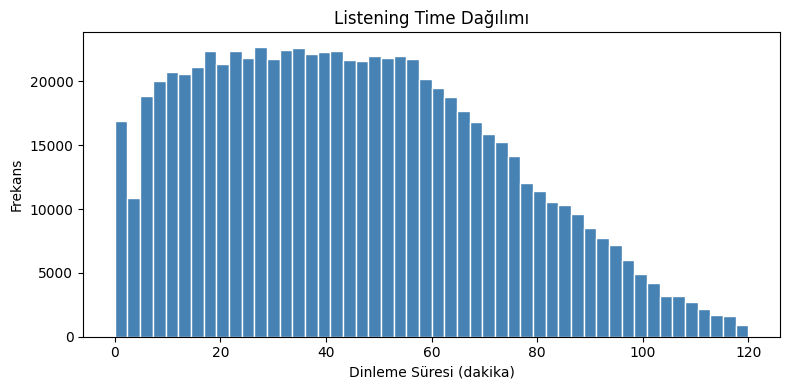

In [12]:
# Listening_Time_minutes Dağılımı
plt.figure(figsize=(8, 4))
plt.hist(train['Listening_Time_minutes'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title('Listening Time Dağılımı')
plt.xlabel('Dinleme Süresi (dakika)')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

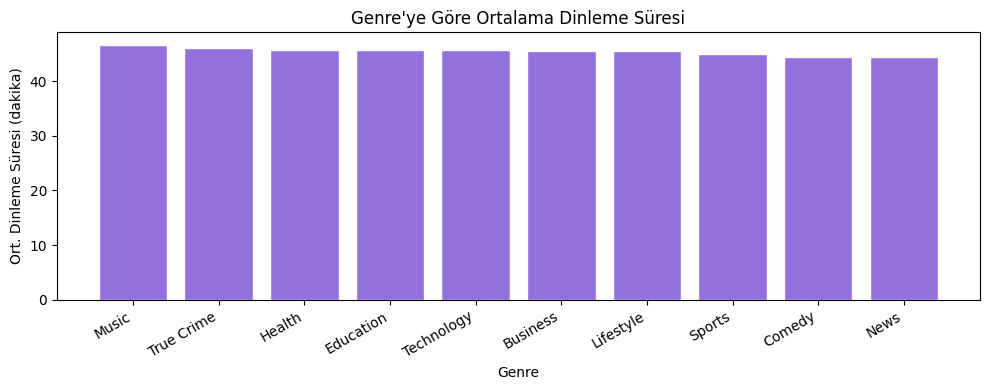

In [13]:
# Genre'ye Göre Ortalama Dinleme Süresi 
genre_mean = train.groupby('Genre')['Listening_Time_minutes'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
plt.bar(genre_mean.index, genre_mean.values, color='mediumpurple', edgecolor='white')
plt.title('Genre\'ye Göre Ortalama Dinleme Süresi')
plt.xlabel('Genre')
plt.ylabel('Ort. Dinleme Süresi (dakika)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

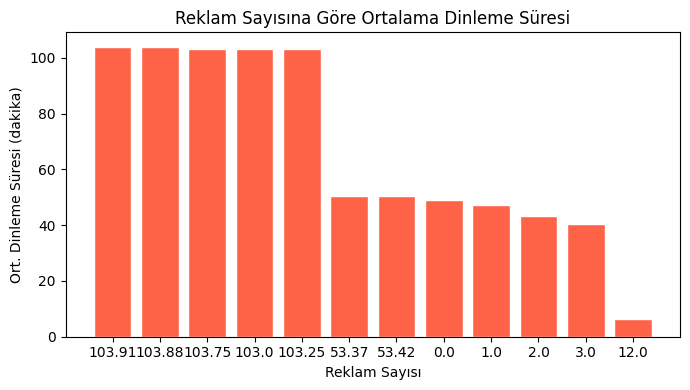

In [14]:
# Number of Ads'e Göre Ortalama Dinleme Süresi 
ads_mean = train.groupby('Number_of_Ads')['Listening_Time_minutes'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(ads_mean.index.astype(str), ads_mean.values, color='tomato', edgecolor='white')
plt.title('Reklam Sayısına Göre Ortalama Dinleme Süresi')
plt.xlabel('Reklam Sayısı')
plt.ylabel('Ort. Dinleme Süresi (dakika)')
plt.tight_layout()
plt.show()

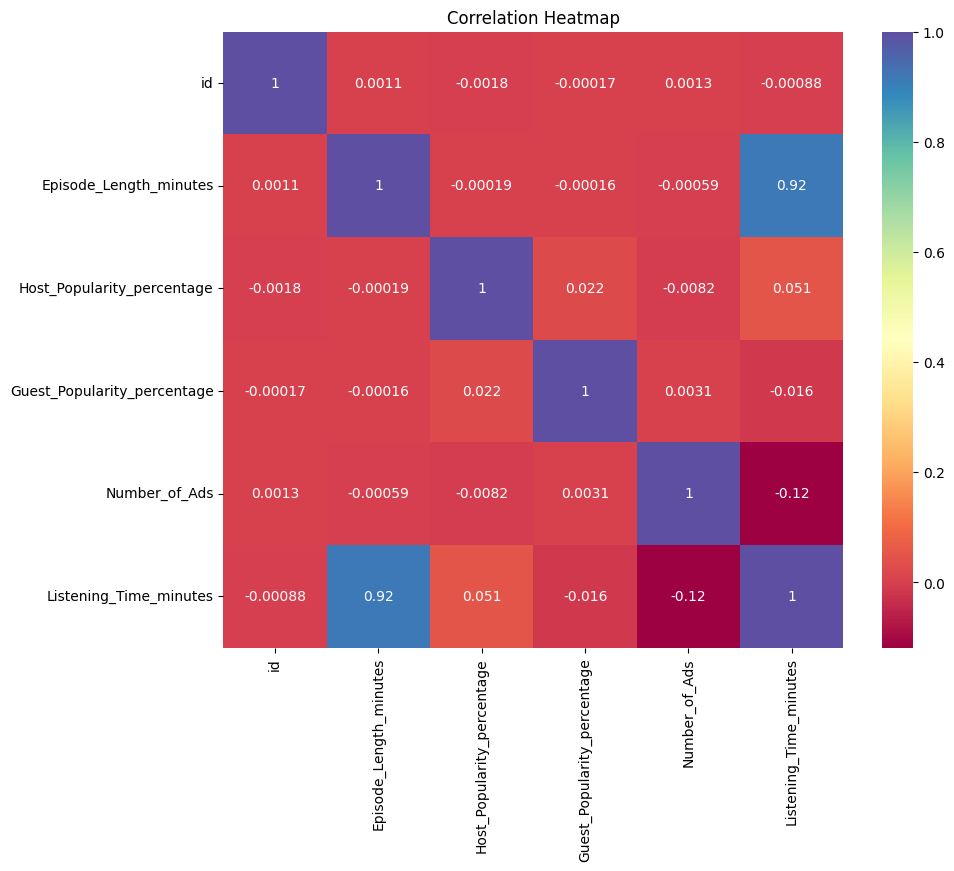

In [15]:
#Korelasyon Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Spectral')
plt.title('Correlation Heatmap')
plt.show()

## Data Prosessing & Feature Engineering

In [16]:
df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,1000000.0,499999.500000,288675.278933,0.0,249999.75000,499999.50000,749999.25000,999999.00
Episode_Length_minutes,884171.0,153.292021,83468.998471,0.0,35.74000,63.87000,94.08000,78486264.00
Host_Popularity_percentage,1000000.0,59.824048,22.874903,1.3,39.37000,60.02000,79.49000,119.46
Guest_Popularity_percentage,805138.0,52.225542,28.449679,0.0,28.37000,53.54000,76.59000,119.91
Number_of_Ads,999999.0,1.350604,2.358272,0.0,0.00000,1.00000,2.00000,2063.00
Listening_Time_minutes,750000.0,45.437406,27.138306,0.0,23.17835,43.37946,64.81158,119.97


In [18]:
df.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes         115829
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    194862
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes         250000
dtype: int64

In [19]:
#Outliers
df.loc[df['Episode_Length_minutes'] > 300, 'Episode_Length_minutes']     = np.nan
df.loc[df['Number_of_Ads'] > 10, 'Number_of_Ads']                        = np.nan
df.loc[df['Host_Popularity_percentage'] > 100, 'Host_Popularity_percentage']   = np.nan
df.loc[df['Guest_Popularity_percentage'] > 100, 'Guest_Popularity_percentage'] = np.nan

In [20]:
#  Episode_Length_minutes
col = 'Episode_Length_minutes'

m1 = train.groupby(['Genre', 'Podcast_Name'])[col].median().reset_index()
m2 = train.groupby('Genre')[col].median().reset_index()
m3 = train[col].median()

# Podcast + Genre
df = df.merge(m1, on=['Genre', 'Podcast_Name'], how='left', suffixes=('', '_m1'))
df[col] = df[col].fillna(df[f'{col}_m1'])
df.drop(columns=f'{col}_m1', inplace=True)

# Genre
df = df.merge(m2, on='Genre', how='left', suffixes=('', '_m2'))
df[col] = df[col].fillna(df[f'{col}_m2'])
df.drop(columns=f'{col}_m2', inplace=True)

# Global
df[col] = df[col].fillna(m3)

In [21]:
col = 'Guest_Popularity_percentage'

m1 = train.groupby('Podcast_Name')[col].median()
m2 = train.groupby('Genre')[col].median()
m3 = train[col].median()

df[col] = df[col].fillna(df['Podcast_Name'].map(m1))
df[col] = df[col].fillna(df['Genre'].map(m2))
df[col] = df[col].fillna(m3)

In [22]:
col = 'Host_Popularity_percentage'

m1 = train.groupby('Podcast_Name')[col].median()
m2 = train.groupby('Genre')[col].median()
m3 = train[col].median()

df[col] = df[col].fillna(df['Podcast_Name'].map(m1))
df[col] = df[col].fillna(df['Genre'].map(m2))
df[col] = df[col].fillna(m3)

In [23]:
ads_mode_overall = train['Number_of_Ads'].mode()[0]

df['Number_of_Ads'].fillna(ads_mode_overall, inplace=True)

In [24]:
df.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes              0
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage         0
Number_of_Ads                       0
Episode_Sentiment                   0
Listening_Time_minutes         250000
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   id                           1000000 non-null  int64  
 1   Podcast_Name                 1000000 non-null  object 
 2   Episode_Title                1000000 non-null  object 
 3   Episode_Length_minutes       1000000 non-null  float64
 4   Genre                        1000000 non-null  object 
 5   Host_Popularity_percentage   1000000 non-null  float64
 6   Publication_Day              1000000 non-null  object 
 7   Publication_Time             1000000 non-null  object 
 8   Guest_Popularity_percentage  1000000 non-null  float64
 9   Number_of_Ads                1000000 non-null  float64
 10  Episode_Sentiment            1000000 non-null  object 
 11  Listening_Time_minutes       750000 non-null   float64
dtypes: float64(5), int64(1), object(6)
memory u

In [26]:
abs(df.corr(numeric_only=True))['Listening_Time_minutes'].sort_values(ascending=False)

Listening_Time_minutes         1.000000
Episode_Length_minutes         0.866353
Number_of_Ads                  0.124208
Host_Popularity_percentage     0.050801
Guest_Popularity_percentage    0.014435
id                             0.000876
Name: Listening_Time_minutes, dtype: float64

In [27]:
df['length_per_ad'] = df['Episode_Length_minutes'] / (df['Number_of_Ads'] + 1)

In [28]:
df['avg_popularity'] = (df['Host_Popularity_percentage'] + df['Guest_Popularity_percentage']) / 2

In [29]:
time_map = {'Morning': 1, 'Afternoon': 2, 'Evening': 3, 'Night': 4}
df['Publication_Time'] = df['Publication_Time'].map(time_map)

In [30]:
sentiment_map = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['Episode_Sentiment'] = df['Episode_Sentiment'].map(sentiment_map)

In [31]:
abs(df.corr(numeric_only=True))['Listening_Time_minutes'].sort_values(ascending=False)

Listening_Time_minutes         1.000000
Episode_Length_minutes         0.866353
length_per_ad                  0.619937
Number_of_Ads                  0.124208
Host_Popularity_percentage     0.050801
Episode_Sentiment              0.039470
avg_popularity                 0.022906
Publication_Time               0.015536
Guest_Popularity_percentage    0.014435
id                             0.000876
Name: Listening_Time_minutes, dtype: float64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   id                           1000000 non-null  int64  
 1   Podcast_Name                 1000000 non-null  object 
 2   Episode_Title                1000000 non-null  object 
 3   Episode_Length_minutes       1000000 non-null  float64
 4   Genre                        1000000 non-null  object 
 5   Host_Popularity_percentage   1000000 non-null  float64
 6   Publication_Day              1000000 non-null  object 
 7   Publication_Time             1000000 non-null  int64  
 8   Guest_Popularity_percentage  1000000 non-null  float64
 9   Number_of_Ads                1000000 non-null  float64
 10  Episode_Sentiment            1000000 non-null  int64  
 11  Listening_Time_minutes       750000 non-null   float64
 12  length_per_ad                1000000 non-nu

In [33]:
#Target endcoding
for col in ['Genre', 'Publication_Day', 'Podcast_Name']:
    target_mean = train.groupby(col)['Listening_Time_minutes'].mean()
    df[col] = df[col].map(target_mean)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   id                           1000000 non-null  int64  
 1   Podcast_Name                 1000000 non-null  float64
 2   Episode_Title                1000000 non-null  object 
 3   Episode_Length_minutes       1000000 non-null  float64
 4   Genre                        1000000 non-null  float64
 5   Host_Popularity_percentage   1000000 non-null  float64
 6   Publication_Day              1000000 non-null  float64
 7   Publication_Time             1000000 non-null  int64  
 8   Guest_Popularity_percentage  1000000 non-null  float64
 9   Number_of_Ads                1000000 non-null  float64
 10  Episode_Sentiment            1000000 non-null  int64  
 11  Listening_Time_minutes       750000 non-null   float64
 12  length_per_ad                1000000 non-nu

In [35]:
features = [
    'Episode_Length_minutes',      
    'length_per_ad',               
    'Number_of_Ads',               
    'Host_Popularity_percentage',  
    'Episode_Sentiment',           
    'Publication_Time',            
    'Genre',
    'Publication_Day',
    'Podcast_Name'
]

## Train Test Split

In [36]:
train = df[df['Listening_Time_minutes'].notna()]
test  = df[df['Listening_Time_minutes'].isna()]

In [37]:
x      = train[features]
y      = train['Listening_Time_minutes']


x_final_test = test[features]

In [38]:
x.head()

,Episode_Length_minutes,length_per_ad,Number_of_Ads,Host_Popularity_percentage,Episode_Sentiment,Publication_Time,Genre,Publication_Day,Podcast_Name
0,63.81,63.810000,0.0,74.81,2,4,46.042507,44.869706,46.018361
1,119.80,39.933333,2.0,66.95,0,2,44.426441,45.326775,42.640909
2,73.90,73.900000,0.0,69.97,0,3,45.736640,46.131411,47.047780
3,67.17,22.390000,2.0,57.22,2,1,45.634749,45.969630,44.769237
4,110.51,27.627500,3.0,80.07,1,2,45.741413,45.969630,46.840078


## Model Training

In [39]:
def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
       
        
        algos=[L,R,Lass,E,ETR,GBR,kn,dt,xgb]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','Extra Tree','Gradient Boosting','KNeighborsRegressor','Decision Tree','XGBRegressor']
        
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.2,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable

In [40]:
algo_test(x,y)

,R_Squared,RMSE,MAE
XGBRegressor,0.767599,13.076951,9.512209
Gradient Boosting,0.765356,13.139923,9.586020
Ridge,0.759660,13.298460,9.739367
Linear,0.759660,13.298460,9.739367
Lasso,0.758821,13.321637,9.746414
ElasticNet,0.758816,13.321788,9.746680
KNeighborsRegressor,0.730661,14.077887,10.020589
Decision Tree,0.547035,18.256621,12.390106
Extra Tree,0.543359,18.330543,12.460273


In [41]:
best_model = XGBRegressor()
best_model.fit(x,y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [42]:
prediction= best_model.predict(x_final_test)

In [43]:
submission = pd.DataFrame({
    'id'    : test['id'].values,
    'price' : prediction
})

In [44]:
submission.head(10)

,id,price
0,750000,54.915890
1,750001,16.565756
2,750002,50.619484
3,750003,75.698166
4,750004,47.748112
5,750005,22.387693
6,750006,85.649063
7,750007,39.767895
8,750008,67.533051
9,750009,74.705933


In [45]:
submission.to_csv('submission.csv', index=False)